# Build A Basic Chatbot with Langgrapg (Graph API)

This langraph is kind of like flow chart

LangGraph Core Concepts

🔵 Node
A node is a unit of work in your graph — basically a Python function that does something.

➡️ Edge
An edge defines the connections between nodes — i.e., what runs next.

📦 State
State is the shared data/memory that flows through the entire graph.

In [8]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph , START , END
from langgraph.graph.message import add_messages

Here this add_messages are called Reducers. the main job of add_messages is like it acts as a list and append all the ans from the model

bag = []
OR
bag: Annotated[list, "add new books, don't throw old ones"]

annotated is like a label

In [9]:
# this State class is going to return of this TypedDict
class State(TypedDict):
    # Messages have the type 'list'. The 'add_messages' function
    # in the annotaton defines how this state key should be updated
    # (in this cae, it appends message to the list, rather that overwritting them)

    messages: list
    # we are describing messages as a list it should be a reducer function that won't replace older messages but will append to the list of messages

# we are going to create a graph with the StateGraph class
# stategraph is the entire graph
graph_builder = StateGraph(State)

In [10]:
graph_builder

In [11]:
# we saved our groq api key in the .env file and we are loading it here
from dotenv import load_dotenv
load_dotenv()

True

In [12]:
from langchain.chat_models import init_chat_model
# we are initializing the chat model with the groq api key
llm = init_chat_model(model="groq:openai/gpt-oss-120b")

In [13]:
a = llm.invoke("What is the capital of France?")

In [14]:
a

AIMessage(content='The capital of France is **Paris**.', additional_kwargs={'reasoning_content': 'User asks: "What is the capital of France?" Simple factual. Answer: Paris.'}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 78, 'total_tokens': 115, 'completion_time': 0.082127266, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.003000914, 'prompt_tokens_details': None, 'queue_time': 0.048962842, 'total_time': 0.08512818}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9dd5acdef7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d867d-2a1c-7fb3-9b29-9560d3e5a204-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 37, 'total_tokens': 115, 'output_token_details': {'reasoning': 19}})

In [15]:
a.content

'The capital of France is **Paris**.'

In [16]:
# Node Functionality
def chatbot(state: State):
    # here key 'messages' is the list of messages in the 'State' Class
    # inside ll.invoke we are passing the input messages to the llm and it will return the response of the llm which will be added to the list of messages in the state
    return {"messages": [llm.invoke(state["messages"])]}

here we are creating a workflow for 1 node

In [17]:
graph_builder = StateGraph(State)
# here we are adding the node to the functionality of the chatbot and we are giving it a name 'llmchatbot' which we will use to add edges to it
graph_builder.add_node("llmchatbot", chatbot)

# adding the edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

#compile the graph
graph = graph_builder.compile()

Here is the workflow

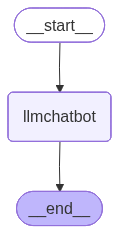

In [18]:
from IPython.display import display , Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is not supported in this environment.")
    print(str(e))

# Without add_messages library

see the difference in the output

In [19]:
graph.invoke({"messages": "What is the capital of France?"})

{'messages': [AIMessage(content='The capital of France is **Paris**.', additional_kwargs={'reasoning_content': 'The user asks: "What is the capital of France?" That\'s a straightforward factual question. The answer: Paris. Should respond succinctly.'}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 78, 'total_tokens': 125, 'completion_time': 0.100050013, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.002910466, 'prompt_tokens_details': None, 'queue_time': 0.044207178, 'total_time': 0.102960479}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_3af5db3300', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d867d-2f82-7281-8109-2bcb89d01458-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 47, 'total_tokens': 125, 'output_token_details': {'reasoning': 29}})]}

In [20]:
graph.invoke({"messages": "What is the capital of France and Belgium?"})

{'messages': [AIMessage(content='- **France:** Paris  \n- **Belgium:** Brussels', additional_kwargs={'reasoning_content': 'The user asks: "What is the capital of France and Belgium?" They want the capitals. Provide answer: Paris is capital of France, Brussels is capital of Belgium. Could also note that each has its own capital. Provide concise answer.'}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 80, 'total_tokens': 150, 'completion_time': 0.148957571, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.003481993, 'prompt_tokens_details': None, 'queue_time': 0.045311497, 'total_time': 0.152439564}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_45da596066', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d867d-3095-77e0-8375-1856958e3957-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 80, 'output_tokens': 70, 'total_tokens': 1

In [21]:
graph.invoke({"messages": "HI"})

{'messages': [AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "HI". We should respond appropriately. Probably greet and ask how can help. Use friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 72, 'total_tokens': 114, 'completion_time': 0.094389933, 'completion_tokens_details': {'reasoning_tokens': 24}, 'prompt_time': 0.014636637, 'prompt_tokens_details': None, 'queue_time': 0.02911989, 'total_time': 0.10902657}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_49bfac06f1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d867d-316c-7393-803a-77edf2e5897e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 42, 'total_tokens': 114, 'output_token_details': {'reasoning': 24}})]}

# With add_messages library

see the difference in the output

In [22]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph , START , END
from langgraph.graph.message import add_messages

In [23]:
class State(TypedDict):
    messages: Annotated[list , add_messages]

graph_builder = StateGraph(State)

In [24]:
def chatbot(state: State):
    return{'messages':[llm.invoke(state['messages'])]}

In [25]:
graph_builder.add_node("llmchatbot", chatbot)

graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

graph = graph_builder.compile()


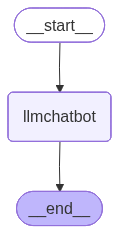

In [26]:
from IPython.display import display , Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is not supported in this environment.")
    print(str(e))

because of add_messages we can store both question and ans

In [27]:
graph.invoke({"messages": "What is the capital of France?"})

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='a0df71e3-6fcd-421a-88cf-d1ad4c8391cf'),
  AIMessage(content='The capital of France is **Paris**.', additional_kwargs={'reasoning_content': 'The user asks a simple factual question. Provide answer: Paris.'}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 78, 'total_tokens': 110, 'completion_time': 0.093815816, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.00321755, 'prompt_tokens_details': None, 'queue_time': 0.019159657, 'total_time': 0.097033366}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9dd5acdef7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d867d-3493-7ff0-8a70-0552880d6901-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 32, 'total_tokens': 110, 'output_token_details': {'reas

In [28]:
response = graph.invoke({"messages": "What is the capital of France?"})

In [29]:
response["messages"][-1].content

'The capital of France is **Paris**.'

In [30]:
a= [1,2,3,4]
a[-1]

4

# ChatBot with Tool

Tavily its like a search engine so that model will get real-time data

In [31]:
from langchain_tavily import TavilySearch

tool = TavilySearch()
tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://simple.wikipedia.org/wiki/Capital_of_France',
   'title': 'Capital of France - Simple English Wikipedia, the free encyclopedia',
   'content': 'This article is about the French national capital in general. For the current capital, see Paris. The capital of France is Paris. In the course of history,',
   'score': 0.93338853,
   'raw_content': None},
  {'url': 'https://home.adelphi.edu/~ca19535/page%204.html',
   'title': 'Paris facts: the capital of France in history',
   'content': '## Paris facts: Paris, the **capital of France**. Paris is the **capital of France**, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011. ## Paris facts: Paris history. From the Romans to the Vth Republic, Paris has a rich 2000 year history. See details of Paris history. ## Paris facts: Paris, a world city.

In [32]:
def multiply(a: int, b: int) -> int:
    # this is docstring this imp and from this llm model understands the function
    """Multiply a and b
    
    Args:
        a (int): first int
        b (int): second int
    """
    return a * b

In [33]:
# here we are creating a list of tools that we want to use in our graph. We can add as many tools as we want to this list and we can use them in our graph by invoking them in the node functions
tools = [tool , multiply]

In [34]:
# Here we combine the llm with the tools using the 'bind_tools' function. This will allow us to use the tools in our node functions by invoking them.
# biniding with llm helps the llm to show which all tools we are using 
llm_with_tools = llm.bind_tools(tools)

In [35]:
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000275F2421A90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000275F3F01400>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input shou

We need to convert this above tools to 'node' for that we use ToolNode function

In [36]:
# Stategraph 
from langgraph.graph import StateGraph , START , END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [37]:
# Node Definition
def tool_calling_llm(state: State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

In [38]:
# Graph
builder  = StateGraph(State)
builder.add_node("tool_calling_llm" ,tool_calling_llm)
builder.add_node("tools" , ToolNode(tools))

In [39]:
# adding edges
builder.add_edge(START , "tool_calling_llm")
# langgprapg automatically do this condition check for us and routes to tools if the latest message from assistant is a tool call and routes to END if it is not a tool call
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message (result) from assistant is not a tool call -> it routes to END
    tools_condition
)
builder.add_edge("tools" , END)

graph = builder.compile()

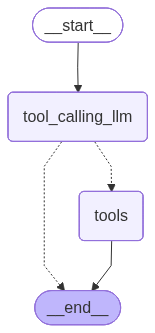

In [40]:
from IPython.display import display , Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is not supported in this environment.")
    print(str(e))

In [41]:
response = graph.invoke({"messages": "What is the recent ai news?"})

In [42]:
response

{'messages': [HumanMessage(content='What is the recent ai news?', additional_kwargs={}, response_metadata={}, id='6bf8c4e0-c8ed-4686-9f34-ae506750fd1e'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "What is the recent ai news?" Likely wants a summary of recent AI news. Need up-to-date info as of now (April 2026). We need to browse recent AI news. Use tavily_search with query "latest AI news April 2026". Probably need multiple sources. Let\'s search.', 'tool_calls': [{'id': 'fc_bd85348b-2287-4ab7-be6f-0215d2ea2c89', 'function': {'arguments': '{"query":"AI news April 2026 latest developments artificial intelligence April 2026","search_depth":"advanced","time_range":"month"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 125, 'prompt_tokens': 349, 'total_tokens': 474, 'completion_time': 0.281139107, 'completion_tokens_details': {'reasoning_tokens': 67}, 'prompt_time': 0.022332485, 'prompt_tokens

In [43]:
response["messages"][-1].content

'{"query": "AI news April 2026 latest developments artificial intelligence April 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://bostoninstituteofanalytics.org/blog/this-week-in-generative-ai-april-4-april-10-2026-why-2026-is-seeing-record-breaking-adoption-rates/", "title": "Generative AI Weekly Apr 4–10 2026 Adoption Boom", "content": "### From Chatting to Doing\\n\\nThe first three days of April 2026 will see global software leaders launch their enterprise updates which will transform “Ask a question” user interfaces into “Execute a workflow” systems. The Agentic AI frameworks now possess the ability to search internal databases while cross-referencing current market data and performing complex transactions without requiring human supervision.\\n\\nA senior researcher from the Boston Institute of Analytics declares that “we are moving from AI that assists us to AI that acts on our behalf. The first quarter of 2026 has seen a threefold i

In [44]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_bd85348b-2287-4ab7-be6f-0215d2ea2c89)
 Call ID: fc_bd85348b-2287-4ab7-be6f-0215d2ea2c89
  Args:
    query: AI news April 2026 latest developments artificial intelligence April 2026
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news April 2026 latest developments artificial intelligence April 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://bostoninstituteofanalytics.org/blog/this-week-in-generative-ai-april-4-april-10-2026-why-2026-is-seeing-record-breaking-adoption-rates/", "title": "Generative AI Weekly Apr 4–10 2026 Adoption Boom", "content": "### From Chatting to Doing\n\nThe first three days of April

In [45]:
response = graph.invoke({"messages": "What is 9 multiplied by 3?"})

In [46]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 9 multiplied by 3?
================================== Ai Message ==================================

9 multiplied by 3 equals **27**.


In [47]:
response = graph.invoke({"messages": "give me the recent ai news and then multiply 5 by 10"})

In [48]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_944679c6-3111-4619-9208-f1abdaf9f0ac)
 Call ID: fc_944679c6-3111-4619-9208-f1abdaf9f0ac
  Args:
    query: latest AI news April 2026
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news April 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.jdsupra.com/legalnews/ai-today-in-5-april-8-2026-the-ai-in-40773/", "title": "AI Today in 5: April 8, 2026, The AI in Professional Services Edition | Thomas Fox - Compliance Evangelist - JD Supra", "score": 0.9995272, "published_date": "Wed, 08 Apr 2026 20:11:40 GMT", "content": "Welcome to AI Today in 5, the newest addi

here normally when we pass a query to llm model it splits the question into different components.
ex: "give me the recent ai news and then multiply 5 by 10"? here there are 2 components ai new and multiply 5 * 10
normally in above code the llm model split the query and get the 1st query ans and move to END
so we won't get the 2nd part ans to solve this problem we are using method called 

# ReAct Agent Architecture

In [49]:
# Graph
builder  = StateGraph(State)
builder.add_node("tool_calling_llm" ,tool_calling_llm)
builder.add_node("tools" , ToolNode(tools))

Here the 1st ans is again passed to the llm model not to the END

In [50]:
# adding edges
builder.add_edge(START , "tool_calling_llm")
# langgprapg automatically do this condition check for us and routes to tools if the latest message from assistant is a tool call and routes to END if it is not a tool call
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    tools_condition
)
# we change the routing here instead of routing to END if it is not a tool call we are routing it back to the llm so that it can keep responding until there is a tool call and then it will route to tools and after using the tool it will route back to the llm again for further response
builder.add_edge("tools" , "tool_calling_llm")

graph = builder.compile()

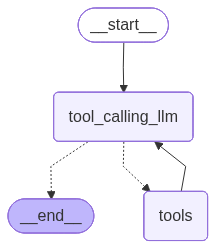

In [51]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [52]:
response = graph.invoke({"messages": "give me the recent ai news and then multiply 5 by 10"})

In [53]:
for m in response["messages"]:
    print(m.content)

give me the recent ai news and then multiply 5 by 10

{"query": "AI news April 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.pwc.com/gx/en/news-room/press-releases/2026/pwc-2026-ai-performance-study.html", "title": "Three-quarters of AI's economic gains are being captured by just 20 ...", "content": "Press Release\n   3 minute read\n   April 13, 2026\n\nShare\n\nCopy Link Link Copied\n\nClose\n\n   The leading companies are approximately two to three times more likely to use AI to identify and pursue growth opportunities and reinvent their business model.\n   They are twice as likely to redesign workflows to incorporate AI rather than simply adding AI tools.\n   They are three times (2.8x) more likely to have increased the number of decisions made without human intervention, while also going further on AI governance.\n\nLONDON, 13 April 2026 – A small group of companies is pulling sharply ahead in the race to generate real financial 

# Adding memory to the model

In [54]:
graph.invoke({"messages": "my name is abhi"})['messages'][-1].content

'Nice to meet you, Abhi! How can I assist you today?'

In [55]:
graph.invoke({"messages": "what is my name"})['messages'][-1].content

'I don’t have any information about your name. If you’d like me to address you by a specific name, just let me know!'

to solve this problem we are adding memory checkpoint to the graph

In [56]:
# Graph
builder  = StateGraph(State)
builder.add_node("tool_calling_llm" ,tool_calling_llm)
builder.add_node("tools" , ToolNode(tools))

In [57]:
from langgraph.checkpoint.memory import MemorySaver
memory_saver = MemorySaver()

In [58]:
# adding edges
builder.add_edge(START , "tool_calling_llm")
# langgprapg automatically do this condition check for us and routes to tools if the latest message from assistant is a tool call and routes to END if it is not a tool call
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    tools_condition
)
# we change the routing here instead of routing to END if it is not a tool call we are routing it back to the llm so that it can keep responding until there is a tool call and then it will route to tools and after using the tool it will route back to the llm again for further response
builder.add_edge("tools" , "tool_calling_llm")

# add this checkpointer to the compile 
graph = builder.compile(checkpointer=memory_saver)

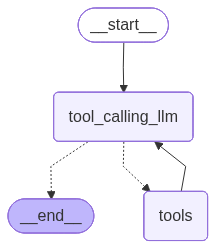

In [59]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [60]:
# after adding checkpoint to the comipler we need an id or thread for the section
config = {"configurable":{"thread_id": "1"}}

response = graph.invoke({"messages": "my name is abhi"}, config=config)

In [61]:
response['messages'][-1].content

"Nice to meet you, Abhi! If there's anything you'd like to chat about or need help with, just let me know."

In [62]:
response = graph.invoke({"messages": "what is my name?"}, config=config)

In [63]:
response['messages'][-1].content

'You told me your name is **Abhi**.'

# Streaming

Methods: stream() and astream()

* These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

* values: This streams the full state of the graph after each node is called
* updates: This streams updates to the state of the graph after each node is called

In [64]:
from langgraph.graph import StateGraph , START , END
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict , Annotated  
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image

In [79]:
class State(TypedDict):
    messages: Annotated[list , add_messages]

graph = StateGraph(State)
memory_saver = MemorySaver()

def superbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

graph.add_node("Superbot" , superbot)

graph.add_edge(START , "Superbot")
graph.add_edge("Superbot" , END)

graph_builder = graph.compile(checkpointer=memory_saver)

config = {"configurable":{"thread_id": "1"}}




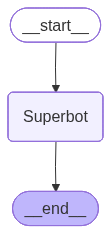

In [66]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [80]:
response = graph_builder.invoke({"messages": "What is the capital of France?"}, config=config , stream_mode="updates")

In [81]:
response

[{'Superbot': {'messages': [AIMessage(content='The capital of France is **Paris**.', additional_kwargs={'reasoning_content': 'The user asks a simple factual question: "What is the capital of France?" The answer: Paris. No policy issues. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 78, 'total_tokens': 125, 'completion_time': 0.101795564, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.014718067, 'prompt_tokens_details': None, 'queue_time': 0.018032653, 'total_time': 0.116513631}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8f6e75019a', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d867f-acb1-7c62-854f-31f4adce2ef5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 47, 'total_tokens': 125, 'output_token_details': {'reasoning': 29}})]}}]

In [82]:
response = graph_builder.invoke({"messages": "What is the capital of India?"}, config=config , stream_mode="values")

In [83]:
response

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='edc8aa1e-59af-4699-a807-7b4333753f6d'),
  AIMessage(content='The capital of France is **Paris**.', additional_kwargs={'reasoning_content': 'The user asks a simple factual question: "What is the capital of France?" The answer: Paris. No policy issues. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 78, 'total_tokens': 125, 'completion_time': 0.101795564, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.014718067, 'prompt_tokens_details': None, 'queue_time': 0.018032653, 'total_time': 0.116513631}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8f6e75019a', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d867f-acb1-7c62-854f-31f4adce2ef5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_

In [84]:
response = graph_builder.invoke({"messages": "What is the capital of France?"}, config=config , stream_mode="updates")

In [85]:
response

[{'Superbot': {'messages': [AIMessage(content='The capital of France is **Paris**.', additional_kwargs={'reasoning_content': 'User asks again: "What is the capital of France?" Already answered. Just respond again.'}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 132, 'total_tokens': 170, 'completion_time': 0.080979311, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.005882411, 'prompt_tokens_details': None, 'queue_time': 0.017623222, 'total_time': 0.086861722}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9dd5acdef7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d8680-4c13-7a70-9127-beaffe1bff4b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 132, 'output_tokens': 38, 'total_tokens': 170, 'output_token_details': {'reasoning': 20}})]}}]

In [86]:
response = graph_builder.invoke({"messages": "What is the capital of USA?"}, config=config , stream_mode="updates")

In [87]:
response

[{'Superbot': {'messages': [AIMessage(content='The capital of the United States of America is **Washington,\u202fD.C.**.', additional_kwargs={'reasoning_content': 'User asks: "What is the capital of USA?" Straight answer: Washington, D.C. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 158, 'total_tokens': 208, 'completion_time': 0.10389492, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.007302347, 'prompt_tokens_details': None, 'queue_time': 0.017909344, 'total_time': 0.111197267}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8520cd3e31', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d8682-f5bb-7091-b632-95fdba486b2e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 158, 'output_tokens': 50, 'total_tokens': 208, 'output_token_details': {'reasoning': 23}})]}}]

# Human in the loop

In [88]:
import os
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="groq:openai/gpt-oss-120b")

In [107]:
from typing_extensions import TypedDict
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool

from langgraph.graph import StateGraph , START , END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode , tools_condition
from langgraph.checkpoint.memory import MemorySaver

from langgraph.types import Command , interrupt

This concept is very simple normally when we download any thing at some point it stops and they ask 'yes or no' from that response the next thing is happening this is that

In [108]:
class State(TypedDict):
    messages: Annotated[list , add_messages]

graph_builder = StateGraph(State)
memory_saver = MemorySaver()

@tool
def human_assistance(query: str)->str:
    # whatever query we are passing to this function it will be interrupted and check
    # this is a doc string where llm model understand the function
    """Request assistance from a human"""
    human_response = interrupt({"query": query})
    # here we are returning the response from the human to the llm 
    return human_response["data"]

tool = TavilySearch(max_results=2)

tools = [tool , human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot" , chatbot)
graph_builder.add_node("tools" , ToolNode(tools))

graph_builder.add_edge(START , "chatbot")
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graph_builder.add_edge("tools" , "chatbot")

graph = graph_builder.compile(checkpointer=memory_saver)

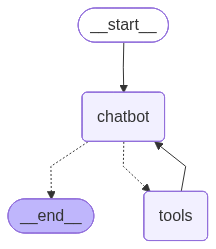

In [109]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [110]:
config = {"configurable":{"thread_id": "1"}}

user_input = "I need some exxpert guidance for building an AI agent. Could you request assistance for me?"

In [ ]:
# graph.invoke — Waits for full response , graph.stream — Shows response as it happens
events = graph.stream({"messages": user_input}, config=config, stream_mode="values")

# You need to iterate over it!
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some exxpert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_7259debc-0ec1-45a5-bec5-e38624f8e5b9)
 Call ID: fc_7259debc-0ec1-45a5-bec5-e38624f8e5b9
  Args:
    query: User requests expert guidance for building an AI agent. Please provide detailed assistance.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_7259debc-0ec1-45a5-bec5-e38624f8e5b9)
 Call ID: fc_7259debc-0ec1-45a5-bec5-e38624f8e5b9
  Args:
    query: User requests expert guidance for building an AI agent. Please provide detailed assistance.


here look our model is asking for more info

In [ ]:
# here llm model is expecting some input from the human
human_response = (
    "We, the experts are here to help! we'd recomment you check out LangGraph to build your AI agent"
    "Its much more reliable and extensible than simple autonomous agents"
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config=config, stream_mode="values")

for event in events:
    event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_7259debc-0ec1-45a5-bec5-e38624f8e5b9)
 Call ID: fc_7259debc-0ec1-45a5-bec5-e38624f8e5b9
  Args:
    query: User requests expert guidance for building an AI agent. Please provide detailed assistance.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! we'd recomment you check out LangGraph to build your AI agentIts much more reliable and extensible than simple autonomous agents
================================== Ai Message ==================================

Absolutely—happy to help you get started building a robust AI agent! Below is a concise, practical roadmap you can follow, along with some recommended tools and best‑practice tips.

---

## 1️⃣ Define the Agent’s Purpose & Scope
| Question | Why It Matters |
|----------|----------------|
| **What problem am I solving?** | Clarifies t

In [116]:
human_response = (
    "We, the experts are here to help! we'd recomment you check out LangGraph to build your AI agent"
    "Its much more reliable and extensible than simple autonomous agents"
)

In [117]:
print(human_response)

We, the experts are here to help! we'd recomment you check out LangGraph to build your AI agentIts much more reliable and extensible than simple autonomous agents
